# Estrategia Trend Following (Time Series Momentum)
## Trabajo práctico — Ingeniería Financiera 

**Grupo:** Agustín Millozi, Diego Lopez Fresco, Lucas Polakoff, y Máximo Castro Darrigo  
**Materia:** Ingeniería Financiera tutoriales  
**Universidad de San Andrés**    
**Fecha:** Mayo 2026

---

> Este notebook documenta el diseño, la base bibliográfica y la arquitectura de una estrategia sistemática de **Trend Following** (también llamada *Time Series Momentum* o TSMOM). Cubre la intuición económica, los papers que la sustentan, el pipeline de implementación y las fórmulas exactas utilizadas.

---
# Sección 1 — Intuición Económica

## 1.1 ¿Por qué el Trend Following funciona?

El Trend Following parte de la observación empírica de que los precios de activos financieros exhiben **autocorrelación positiva a horizontes de 1 a 12 meses**, es decir, lo que subió tiende a seguir subiendo, y lo que bajó tiende a seguir bajando. Esta persistencia no es una anomalía efímera, sino que tiene tres explicaciones estructurales bien documentadas:

### 1.1.1 Underreaction (Reacción lenta)

Los inversores procesan la información de forma **gradual y sesgada**. Cuando llega una noticia positiva sobre un activo:

- Los inversores institucionales grandes tardan en acumular posiciones por restricciones de capacidad y de mandato.
- Los analistas de sell-side actualizan sus modelos lentamente para no quedar expuestos a ser los primeros en el cambio.
- El mercado incorpora la información de forma **serial** en lugar de inmediata, creando una tendencia gradual al alza.

El resultado es que el precio sube por etapas durante varios meses, generando la señal que capta TSMOM.

### 1.1.2 Overreaction (Sobrereacción)

En fases avanzadas del ciclo, la misma tendencia que atrajo capital moderado ahora atrae **capital especulativo de menor criterio**. Esto genera:

- **Herding**: los fondos siguen a otros fondos, amplificando la señal original más allá del fundamental.
- **Disposición effect**: los inversores con ganancias cierran posiciones antes de tiempo (frenando el upside) mientras que los que tienen pérdidas las mantienen demasiado (acelerando el downside en la reversión).
- **Feedback loops**: los stops loss automatizados y margin calls producen ventas forzadas que amplifican tendencias bajistas.

La sobrereacción explica por qué las tendencias terminan en reversiones bruscas — las mismas que el **crash filter** de Daniel & Moskowitz (2016) busca mitigar.

### 1.1.3 Fricción Institucional

Los mercados no son libres de fricciones. Los inversores institucionales enfrentan:

- **Restricciones de mandato**: muchos fondos de pensión no pueden vender activos en caída libre aunque reconozcan la tendencia.
- **Horizonte de evaluación corto**: los gestores son medidos trimestral o anualmente, lo que desincentiva posiciones contratendencia de largo plazo.
- **Costos de rebalanceo**: la fricción de transacción impide corrección instantánea de precios desalineados.
- **Regulación y restricciones de capital**: límites de concentración, VaR regulatorio y cobertura de pasivos crean demanda estructural (hedging pressure) que genera tendencias persistentes en futuros de renta fija y divisas.

Estas fricciones son la razón por la que Hurst, Ooi & Pedersen (2017) muestran que el TSMOM ha funcionado durante **un siglo** en múltiples clases de activos: son una característica estructural del sistema financiero, no una anomalía transitoria.

---

## 1.2 Time Series Momentum vs Cross-Sectional Momentum

Ambas estrategias explotan el mismo fenómeno de fondo — la persistencia del rendimiento — pero lo hacen de maneras fundamentalmente distintas:

| Dimensión | **Time Series Momentum (TSMOM)** | **Cross-Sectional Momentum (XSMOM)** |
|-----------|-----------------------------------|---------------------------------------|
| **Señal** | Rendimiento pasado del activo contra sí mismo (¿subió o bajó?) | Rendimiento pasado del activo contra el universo (¿es mejor o peor que los demás?) |
| **Posición** | Long o short según signo de retorno | Long los mejores, short los peores; siempre market-neutral |
| **Exposición de mercado** | Puede tener beta positivo o negativo según el régimen | Beta cercana a cero por construcción |
| **Referencia temporal** | Ventana de 12 meses (usualmente) contra el propio activo | Ranking relativo en un corte transversal dado |
| **Universo requerido** | Puede operar un solo activo | Requiere un universo de activos para rankear |
| **Diversificación** | A través de múltiples clases de activos | A través de muchos activos dentro de una clase |
| **Desempeño en crashes** | **Funciona bien** en tendencias bajistas prolongadas (short) | **Colapsa** en reversiones bruscas (momentum crash) |
| **Paper fundacional** | Moskowitz, Ooi & Pedersen (2012) | Jegadeesh & Titman (1993) |
| **Aplicación típica** | CTAs, fondos macro sistemáticos | Fondos equity long-short, factor investing |
| **Intuición** | "Este activo viene subiendo, seguir long" | "Esta acción viene mejor que sus pares, comprarla" |

### ¿Por qué elegimos TSMOM?

Nuestra estrategia implementa **Time Series Momentum** porque:

1. **Opera en múltiples clases de activos** (futuros de equity, bonos, commodities, FX) donde el XSMOM no aplica directamente.
2. **La exposición variable es una feature, no un bug**: en crisis prolongadas, el TSMOM se pone short y genera retornos positivos, funcionando como seguro natural del portafolio.
3. **Menor dependencia del universo**: no necesitamos un universo amplio para rankear activos, lo que reduce el riesgo de overfitting en la selección del universo.
4. **Mejor adaptación al framework de CTA**: es el modelo estándar de los fondos de managed futures que son nuestra referencia institucional.

---
# Sección 2 — Base Bibliográfica y Cómo se Aplica

Esta sección presenta los cuatro papers que fundamentan cada componente de la estrategia. Para cada uno se describe su contribución teórica y qué elementos concretos tomamos de él.

---

## Paper 1: Moskowitz, Ooi & Pedersen (2012)
### *"Time Series Momentum"* — Journal of Financial Economics

### Qué dice el paper

Este paper es la piedra fundacional del TSMOM sistemático. Los autores analizan **58 activos** (futuros de equity, bonos, divisas y commodities) durante 25 años y documentan que:

- Los retornos pasados a 1, 3, 6 y 12 meses predicen positivamente los retornos futuros.
- La señal de **12 meses** es la más robusta estadística y económicamente.
- Una estrategia que va long activos con retorno positivo de 12 meses y short activos con retorno negativo genera un **Sharpe ratio de ~1.0** sostenido a través de décadas.
- La estrategia **funciona especialmente bien en los extremos del mercado**: en los peores meses de crisis (como 2008), los activos que ya venían bajando siguieron bajando, y el TSMOM generó retornos positivos al estar short en ellos.

El mecanismo: los inversores *underreactan* inicialmente a las noticias (gradual incorporation) y luego *overreactan* (herding), generando autocorrelación positiva en la fase intermedia.

### Qué tomamos de este paper

**1. Señal de momentum simple:**

$$s_t = \text{sign}\left(r_{t-12:t}\right)$$

donde $r_{t-12:t}$ es el retorno acumulado de los últimos 12 meses. Si el activo subió, $s_t = +1$ (long); si bajó, $s_t = -1$ (short). Es binaria y simple.

**2. Estimación de volatilidad con EWMA:**

$$\hat{\sigma}_t^2 = \frac{1-\lambda}{1-\lambda^T} \sum_{i=0}^{T-1} \lambda^i r_{t-i}^2$$

donde $\lambda = \frac{\text{COM}}{\text{COM}+1}$ con $\text{COM} = 3$ (Center of Mass = 3 días $\approx$ 60 días de media ponderada efectiva). Usamos retornos al cuadrado en lugar de retornos menos media para robustez en series con drift.

**3. Sizing por volatility targeting por activo:**

$$w_i = s_i \cdot \frac{\sigma^*}{N. \hat{\sigma}_i}$$

donde $\sigma^* = 40\%$ anualizado es el **vol target por activo**. Cada activo recibe un tamaño de posición que escala inversamente con su volatilidad realizada, de forma que todos los activos contribuyen con el mismo riesgo esperado independientemente de cuán volátiles sean.

---

## Paper 2: Baz, Granger, Harvey, Le Roux & Rattray (2015)
### *"Dissecting Investment Strategies in the Cross Section and Time Series"* — SSRN

### Qué dice el paper

Los autores de Man AHL (uno de los CTAs más grandes del mundo) proponen un framework más sofisticado para modelar tendencias. Su observación central es que las tendencias operan en **múltiples horizontes temporales simultáneamente**: una tendencia de largo plazo puede coexistir con una corrección de corto plazo en el mismo activo.

Introducen la **señal CTA multi-horizonte** que combina tres ventanas temporales (corto, medio y largo plazo) con una función de respuesta $R(x)$ que transforma la magnitud del z-score de tendencia en una posición bounded entre $[-1, +1]$.
- **El z-score** responde a la pregunta: ¿qué tan inusual es este número comparado con su historia? 
- Sí z=0 --> el valor está exactamente en el promdio historico. Señal neutra.
- z>0 --> el valor esta n unidades desvió por encima del promedio histórico. Tendencia alcista.

La función $R(x)$ tiene propiedades cruciales:
- Es **monotónica creciente** alrededor de cero (señal débil → posición proporcional)
- **Satura hacia ±1** para señales extremas (no permite posiciones ilimitadas por momentum extremo)
- Esto crea un **crash filter implícito**: cuando la tendencia es demasiado extrema (y frecuentemente es el peak), la posición no aumenta más.

### Qué tomamos de este paper

**1. Señal CTA multi-horizonte:**

Para cada horizonte $h \in \{1, 3, 12\}$ meses, se calcula un z-score de tendencia:

$$z_{i,h} = \frac{\mu_{i,h}}{\hat{\sigma}_{i,h}}$$

donde $\mu_{i,h}$ es la media de retornos en la ventana de $h$ meses y $\hat{\sigma}_{i,h}$ es la volatilidad estimada en esa ventana.

Esta es una versión simplificada de la señal de CTA, en el paper realmente son 4 pasos encadenados antes de llegar al z score. Partiendo de la resta de dos medias móviles (EWMA corta menos EWMA larga) → captura la tendencia.

**2. Función de respuesta no-lineal:**

$$R(x) = x \cdot \exp\left(-\frac{x^2}{4}\right) \cdot \frac{1}{0.89}$$

Esta función mapea $x \in \mathbb{R}$ a posiciones en $(-1, +1)$. El factor $\frac{1}{0.89}$ normaliza para que el máximo sea 1. La función alcanza su máximo en $x = \sqrt{2} \approx 1.41$ y luego decrece, penalizando señales extremas.

**3. Señal combinada:**

$$s_i^{\text{CTA}} = \frac{1}{3} \sum_{h \in \{1,3,12\}} R(z_{i,h})$$

Los tres horizontes reciben peso igual $\frac{1}{3}$. Esto permite que el activo capture tendencias en diferentes escalas de tiempo simultáneamente, reduciendo la dependencia de un único horizonte.

---

## Paper 3: Hurst, Ooi & Pedersen (2017)
### *"A Century of Evidence on Trend-Following Investing"* — Journal of Portfolio Management

### Qué dice el paper

AQR extiende el análisis de TSMOM a **100+ años de datos** (1880-2012) en 67 mercados de múltiples clases de activos. Sus hallazgos principales:

1. **Consistencia secular**: el TSMOM ha funcionado en cada década del siglo pasado, incluyendo períodos pre-computacionales, pre-derivados y pre-globalización financiera.
2. **Robustez entre clases**: funciona en equity, renta fija, commodities y divisas con Sharpe ratios similares.
3. **Análisis por régimen macroeconómico**: el TSMOM desempeña especialmente bien en los **extremos del ciclo económico** — recesiones profundas y booms inflacionarios — porque estos períodos generan tendencias largas y sostenidas. En regímenes tranquilos, el alpha es menor.
4. **Descorrelación**: el TSMOM tiene baja correlación con equity, bonos y otros factores, lo que lo hace valioso como diversificador de portafolio.

El paper también introduce el concepto de **portfolio-level volatility targeting** como práctica estándar de la industria CTA. Agrega una segunda capa de control que dice: "no importa lo que pase a nivel individual, el portafolio total nunca va a tener más del 10% de volatilidad anualizada".

### Qué tomamos de este paper

**Vol target a nivel portafolio:**

Además del vol target por activo (tomado de Moskowitz), aplicamos un **escalado del portafolio agregado** a un target del $\sigma^{\text{port}} = 10\%$ anualizado:

$$w^{\text{port}} = \frac{\sigma^{\text{port}}}{\hat{\sigma}_{\text{portafolio}}}$$

donde $\hat{\sigma}_{\text{portafolio}}$ se estima con la varianza del portafolio combinado (considerando correlaciones):

$$\hat{\sigma}_{\text{portafolio}} = \sqrt{\mathbf{w}^\top \boldsymbol{\Sigma} \mathbf{w}}$$

Esta capa de control adicional evita que el portafolio total exceda el riesgo objetivo incluso cuando todas las señales coinciden en la misma dirección (concentración momentánea de riesgo).

**Análisis por régimen**: el framework de evaluación del backtest incluye descomposición por régimen macroeconómico (expansión/recesión, inflación alta/baja) siguiendo la metodología del paper.

---

## Paper 4: Daniel & Moskowitz (2016)
### *"Momentum Crashes"* — Journal of Financial Economics

### Qué dice el paper

Daniel & Moskowitz descubrieron en este paper que el momentum tiene un punto débil: los *momentum crashes*. Usando datos de 1927 a 2012, los autores muestran que:

1. **El retorno del momentum tiene skewness negativa**: la mayoría de las veces genera retornos modestos positivos, pero ocasionalmente sufre pérdidas catastróficas de -40% a -80% en meses.
2. **Los crashes ocurren en reversiones post-pánico**: cuando el mercado cae abruptamente y luego rebota, la estrategia momentum (short en los peores activos = ahora los que más rebotan, long en los mejores = ahora los más castigados) pierde en ambas patas.
3. **La volatilidad predice los crashes**: los momentum crashes ocurren sistemáticamente en entornos de alta volatilidad realizada que sigue a un período de volatilidad baja. La volatilidad elevada es la señal de alerta.
4. **El crash es predecible**: a diferencia de los retornos medios, el riesgo de crash condicional puede estimarse ex-ante, lo que permite reducir exposición preventivamente.

El paper propone un **crash filter dinámico** basado en la ratio de volatilidad realizada reciente vs. histórica.

### Qué tomamos de este paper

**Crash filter dinámico:**

Definimos la ratio de volatilidad:

$$\phi_t = \frac{\hat{\sigma}_t^{\text{short}}}{\hat{\sigma}_t^{\text{long}}}$$

donde $\hat{\sigma}_t^{\text{short}}$ es la volatilidad realizada reciente (últimos 21 días) y $\hat{\sigma}_t^{\text{long}}$ es la volatilidad histórica de largo plazo (últimos 252 días).

Cuando $\phi_t > 1.5$ (la volatilidad reciente supera en 50% a la histórica), estamos en un entorno de alto riesgo de crash y se reduce la exposición:

$$w_i^{\text{final}} = w_i \cdot \min\left(1, \frac{1.5}{\phi_t}\right)$$

Este ajuste es **continuo** (no binario): si $\phi_t = 2.0$, el peso se escala a $\frac{1.5}{2.0} = 75\%$ de la posición original. Si $\phi_t = 1.5$, no hay ajuste.

---
# Sección 3 — Arquitectura del Sistema

## 3.1 Visión General

El sistema está organizado como un **pipeline lineal** donde cada módulo tiene una responsabilidad única y pasa su output al siguiente. La separación de responsabilidades facilita el testing individual, la sustitución de componentes y la extensión futura.

```
┌─────────────────────────────────────────────────────────────────┐
│                        PIPELINE PRINCIPAL                        │
│                                                                  │
│  Datos         Señal          Portafolio      Ejecución          │
│  ─────         ─────          ──────────      ─────────          │
│                                                                  │
│  main.py  ──►  signal.py  ──►  portfolio.py  ──►  broker.py     │
│     │               │               │                            │
│     │          backtest.py     risk.py                           │
│     │          (evaluación)   (capas de riesgo)                  │
│     │                                                            │
│     └──────── orquesta el flujo completo ──────────────────────► │
└─────────────────────────────────────────────────────────────────┘
```

## 3.2 Descripción de Módulos

| Módulo | Responsabilidad | Input | Output | Papers que sustenta |
|--------|----------------|-------|--------|---------------------|
| `signal.py` | Calcular señales de momentum (simple y CTA) y estimación de volatilidad por activo | Precios diarios OHLCV | Serie temporal de señales $s_{i,t} \in [-1, +1]$ | Moskowitz (2012), Baz (2015) |
| `portfolio.py` | Construir pesos de posición aplicando vol targeting por activo y por portafolio | Señales $s_{i,t}$, volatilidades $\hat{\sigma}_{i,t}$ | Pesos $w_{i,t}$ | Moskowitz (2012), Hurst (2017) |
| `risk.py` | Aplicar capas de gestión de riesgo: crash filter, límites de leverage y concentración | Pesos del portafolio, vol realizada | Pesos ajustados por riesgo $w_{i,t}^{\text{final}}$ | Daniel & Moskowitz (2016) |
| `backtest.py` | Simular la estrategia históricamente con costos de transacción realistas y calcular métricas de performance | Pesos $w_{i,t}^{\text{final}}$, precios | Equity curve, Sharpe, drawdowns, análisis por régimen | Hurst (2017) |
| `broker.py` | Interfaz de ejecución: traducir pesos objetivo a órdenes reales, manejar slippage y costos | Pesos objetivo, precios de mercado | Órdenes ejecutadas, P&L realizado | — |
| `main.py` | Orquestador del pipeline: descarga datos, ejecuta el flujo completo, genera reportes | Config, fechas | Reportes HTML/PDF con resultados | — |

## 3.3 Flujo de Datos Detallado

```
main.py
  │
  ├─► [1] Carga configuración (universo de activos, fechas, parámetros)
  │
  ├─► [2] signal.py
  │         ├── Calcula retornos diarios: r_t = log(P_t / P_{t-1})
  │         ├── Estima volatilidad EWMA: σ̂_t (COM=3, anualizado)
  │         ├── Señal simple: sign(r_{t-12:t})
  │         └── Señal CTA: R(z_h) promediado en h={1,3,12} meses
  │
  ├─► [3] portfolio.py
  │         ├── Sizing por activo: w_i = s_i × (σ* / σ̂_i)  [σ*=40%]
  │         ├── Vol portafolio: σ̂_port = √(w'Σw)
  │         └── Escala portafolio: w_port = w × (10% / σ̂_port)
  │
  ├─► [4] risk.py
  │         ├── Crash filter: φ_t = σ_short / σ_long
  │         ├── Si φ_t > 1.5: reduce w × min(1, 1.5/φ_t)
  │         ├── Límite de leverage: cap_aggregate_gross_exposure
  │         └── Límite de concentración: max_single_asset_weight
  │
  ├─► [5] backtest.py  (modo histórico)
  │         ├── Simula con costos de transacción
  │         ├── Calcula equity curve, drawdowns
  │         └── Desglosa performance por régimen macro
  │
  └─► [6] broker.py  (modo live)
            ├── Calcula diferencia entre posición actual y objetivo
            ├── Genera órdenes (market/limit según configuración)
            └── Registra ejecución y actualiza estado del portafolio
```

## 3.4 Principios de Diseño

- **Separación de señal y sizing**: la señal decide *dirección*, el sizing decide *magnitud*. Son independientes y pueden modificarse sin afectar al otro.
- **Sin look-ahead bias**: cada cálculo solo usa información disponible en $t-1$ (o antes) para generar posiciones en $t$.
- **Reproducibilidad**: todos los parámetros se centralizan en un archivo de configuración; no hay constantes mágicas en el código.
- **Testabilidad**: cada módulo puede instanciarse y testearse con datos sintéticos sin depender del resto del pipeline.

---
# Sección 4 — Diseño de la Señal

## 4.1 Señal Simple (Moskowitz et al., 2012)

### Fórmula

$$\boxed{s_{i,t} = \text{sign}\left(r_{i,\,t-252:t}\right)}$$

donde:

| Variable | Definición |
|----------|------------|
| $s_{i,t}$ | Señal del activo $i$ en el día $t$; toma valores $\{-1, +1\}$ |
| $r_{i,\,t-252:t}$ | Retorno log-acumulado del activo $i$ en los últimos 252 días de trading ($\approx$ 12 meses) |
| $\text{sign}(\cdot)$ | Función signo: $+1$ si el argumento es positivo, $-1$ si es negativo |

### Estimación de Volatilidad (EWMA)

La volatilidad diaria de cada activo se estima con un **Exponentially Weighted Moving Average**:

$$\hat{\sigma}_{i,t}^2 = (1 - \lambda) \sum_{k=0}^{\infty} \lambda^k \, r_{i,t-k}^2$$

con:

$$\lambda = \frac{\text{COM}}{\text{COM} + 1} = \frac{3}{4} = 0.75$$

Para anualizarla:

$$\hat{\sigma}_{i,t}^{\text{anual}} = \hat{\sigma}_{i,t}^{\text{diaria}} \times \sqrt{252}$$

**Decisiones de diseño:**
- Usamos $r^2$ en lugar de $(r - \bar{r})^2$ porque en series financieras la media es económicamente cero a horizontes cortos, y los cuadrados dan menor varianza de estimación.
- El COM = 3 (half-life $\approx$ 2.1 días) es deliberadamente corto: queremos capturar cambios de régimen de volatilidad rápidamente, no con lag de semanas.
- La fórmula recursiva equivalente para implementación eficiente: $\hat{\sigma}_{i,t}^2 = \lambda \hat{\sigma}_{i,t-1}^2 + (1-\lambda) r_{i,t}^2$.

---

## 4.2 Señal CTA Multi-Horizonte (Baz et al., 2015)

### Paso 1: Z-score por horizonte

Para cada activo $i$ y horizonte $h \in \{21, 63, 252\}$ días de trading ($\approx$ 1, 3, 12 meses):

$$z_{i,h,t} = \frac{\bar{r}_{i,h,t}}{\hat{\sigma}_{i,h,t}}$$

donde:

| Variable | Definición |
|----------|------------|
| $\bar{r}_{i,h,t}$ | Media de retornos diarios en la ventana de $h$ días hasta $t$ |
| $\hat{\sigma}_{i,h,t}$ | Desviación estándar de retornos en la misma ventana de $h$ días |
| $z_{i,h,t}$ | Z-score de la tendencia: qué tan "estadísticamente significativa" es la tendencia en el horizonte $h$ |

### Paso 2: Función de respuesta no-lineal

$$\boxed{R(x) = \frac{x \cdot e^{-x^2/4}}{0.89}}$$

**Propiedades de $R(x)$:**

- **Continuidad y antisimetría**: $R(-x) = -R(x)$, preserva la dirección de la señal.
- **Linealidad para señales débiles**: para $|x| \ll 1$, $R(x) \approx x/0.89$, comportamiento proporcional.
- **Saturación para señales fuertes**: para $|x| \gg 1$, $R(x) \to 0$, posición se reduce.
- **Máximo en $x^* = \sqrt{2}$**: $R(\sqrt{2}) \approx 1$. Señales más extremas reciben *menos* posición.
- **Factor de normalización 0.89**: es el máximo de $x \cdot e^{-x^2/4}$, de modo que $\max R(x) = 1$.

La función actúa como un **filtro de anti-sobreconvicción**: el sistema no escala infinitamente su posición cuando la tendencia es extrema, porque las tendencias extremas frecuentemente terminan en reversiones.

### Paso 3: Señal combinada

$$\boxed{s_{i,t}^{\text{CTA}} = \frac{1}{3}\left[R(z_{i,21,t}) + R(z_{i,63,t}) + R(z_{i,252,t})\right]}$$

La señal final es el promedio simple de las tres contribuciones. El resultado está en $(-1, +1)$.

**Decisión de diseño:** pesos iguales entre horizontes porque no hay evidencia empírica robusta de que un horizonte domine consistentemente; el promedio igual maximiza la estabilidad out-of-sample.

---

## 4.3 Comparación de Señales

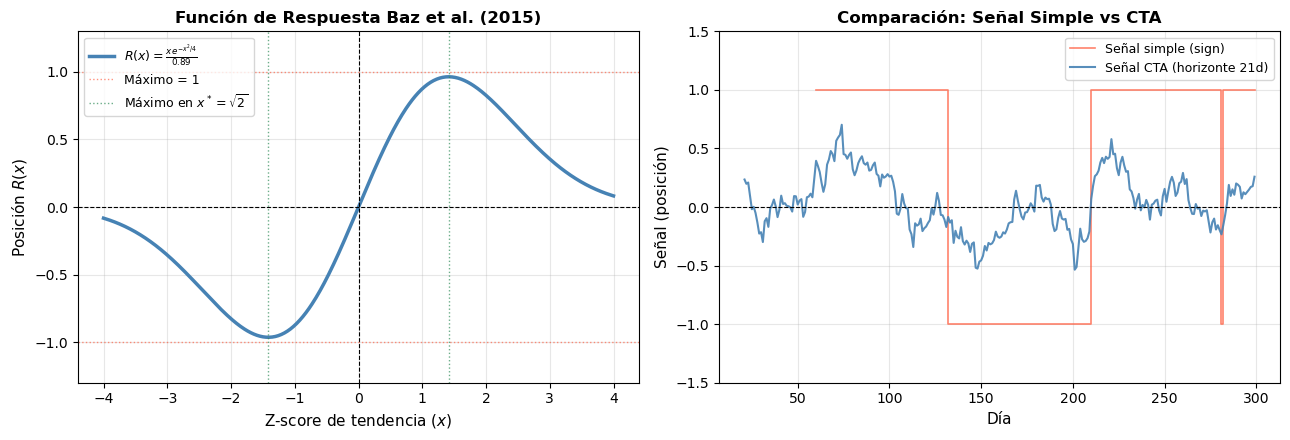

Figura guardada como signal_comparison.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def response_function(x):
    return x * np.exp(-x**2 / 4) / 0.89

x = np.linspace(-4, 4, 500)
y = response_function(x)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Panel izquierdo: función R(x) ---
ax = axes[0]
ax.plot(x, y, color='steelblue', lw=2.5, label=r'$R(x) = \frac{x\,e^{-x^2/4}}{0.89}$')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.axhline(1,  color='tomato', lw=1, ls=':', alpha=0.7, label='Máximo = 1')
ax.axhline(-1, color='tomato', lw=1, ls=':', alpha=0.7)
ax.axvline(np.sqrt(2),  color='seagreen', lw=1, ls=':', alpha=0.7,
           label=r'Máximo en $x^*=\sqrt{2}$')
ax.axvline(-np.sqrt(2), color='seagreen', lw=1, ls=':', alpha=0.7)
ax.set_xlabel('Z-score de tendencia ($x$)', fontsize=11)
ax.set_ylabel('Posición $R(x)$', fontsize=11)
ax.set_title('Función de Respuesta Baz et al. (2015)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(-1.3, 1.3)
ax.grid(alpha=0.3)

# --- Panel derecho: comparación señal simple vs CTA con retornos simulados ---
ax2 = axes[1]
np.random.seed(42)
t = np.arange(300)
# Simular retornos con tendencia embebida
drift = np.concatenate([np.ones(100)*0.003, -np.ones(100)*0.002, np.ones(100)*0.001])
rets = drift + np.random.randn(300) * 0.01
prices = 100 * np.exp(np.cumsum(rets))

# Señal simple (sign de retorno 60-días para visualización clara)
roll_ret = np.array([rets[max(0,i-60):i].sum() if i>=60 else np.nan for i in range(300)])
simple_signal = np.sign(roll_ret)

# Señal CTA (horizonte 21 días para visualización)
roll_mean = np.array([rets[max(0,i-21):i].mean() if i>=21 else np.nan for i in range(300)])
roll_std  = np.array([rets[max(0,i-21):i].std()  if i>=21 else np.nan for i in range(300)])
z_score   = roll_mean / (roll_std + 1e-10)
cta_signal = response_function(z_score)

ax2.plot(t, simple_signal, color='tomato', lw=1.2, alpha=0.8, label='Señal simple (sign)', drawstyle='steps-post')
ax2.plot(t, cta_signal,    color='steelblue', lw=1.5, alpha=0.9, label='Señal CTA (horizonte 21d)')
ax2.axhline(0, color='black', lw=0.8, ls='--')
ax2.set_xlabel('Día', fontsize=11)
ax2.set_ylabel('Señal (posición)', fontsize=11)
ax2.set_title('Comparación: Señal Simple vs CTA', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.savefig('signal_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada como signal_comparison.png")

*La señal simple (roja) es binaria — salta entre -1 y +1. La señal CTA (azul) es continua y gradual, con posiciones intermedias proporcionales a la fuerza de la tendencia. Esto produce menor rotación de portafolio y menor costo de transacción.*

---
# Sección 5 — Construcción del Portafolio y Gestión de Riesgo

## 5.1 Sizing por Activo (Capa 1)

El primer nivel de sizing convierte la señal en un tamaño de posición proporcional al riesgo:

$$\boxed{w_{i,t} = s_{i,t} \cdot \frac{\sigma^*}{\hat{\sigma}_{i,t}^{\text{anual}}}}$$

| Variable | Definición |
|----------|------------|
| $w_{i,t}$ | Peso objetivo del activo $i$ en el portafolio en el día $t$ |
| $s_{i,t}$ | Señal de dirección: $\{-1, +1\}$ para señal simple, $(-1, +1)$ para señal CTA |
| $\sigma^*$ | Vol target por activo = **40% anualizado** (calibrado por Moskowitz et al.) |
| $\hat{\sigma}_{i,t}^{\text{anual}}$ | Volatilidad EWMA anualizada del activo $i$ en $t$ |

**Intuición:** si un activo tiene volatilidad 20% y otro tiene 40%, el primero recibirá el doble del tamaño de posición nominal, de modo que ambos contribuyan el mismo riesgo esperado de 40%. El portafolio es *risk-parity* dentro de cada clase de activo.

**Nota importante:** el peso $w_{i,t}$ no está acotado a $[0,1]$. Si la volatilidad de un activo es muy baja, el peso puede superar 1 (implica leverage). Esto se controla en capas posteriores.

---

## 5.2 Volatility Targeting del Portafolio (Capa 2)

El segundo nivel escala el portafolio completo para que su volatilidad esperada sea $\sigma^{\text{port}} = 10\%$ anualizado:

**Estimación de la volatilidad del portafolio:**

$$\hat{\sigma}_{t}^{\text{port}} = \sqrt{\mathbf{w}_t^\top \, \boldsymbol{\Sigma}_t \, \mathbf{w}_t}$$

donde $\boldsymbol{\Sigma}_t$ es la matriz de covarianza estimada (EWMA de ventana 60 días).

**Escalar a vol target:**

$$\boxed{\mathbf{w}_t^{\text{scaled}} = \mathbf{w}_t \cdot \frac{\sigma^{\text{port}}}{\hat{\sigma}_t^{\text{port}}}}$$

con $\sigma^{\text{port}} = 10\%$.

**Decisión de diseño:** elegimos 10% porque es el estándar de la industria CTA para fondos con perfil de riesgo moderado (permite añadir apalancamiento en contextos institucionales para llegar a targets de 15-20% sin cambiar la estrategia).

**Interacción con Capa 1:** la Capa 1 iguala riesgo entre activos (diversificación inteligente). La Capa 2 calibra el riesgo absoluto total del portafolio. Son complementarias, no redundantes.

---

## 5.3 Crash Filter Dinámico (Capa 3 — Daniel & Moskowitz, 2016)

El tercer nivel ajusta la exposición cuando la volatilidad realizada reciente es anormalmente alta:

**Ratio de volatilidad:**

$$\phi_{i,t} = \frac{\hat{\sigma}_{i,t}^{(21)}}{\hat{\sigma}_{i,t}^{(252)}}$$

donde $\hat{\sigma}^{(21)}$ y $\hat{\sigma}^{(252)}$ son las volatilidades realizadas a 21 y 252 días respectivamente.

**Ajuste del peso:**

$$\boxed{w_{i,t}^{\text{final}} = w_{i,t}^{\text{scaled}} \cdot \min\left(1,\; \frac{1.5}{\phi_{i,t}}\right)}$$

| Condición | $\phi_{i,t}$ | Factor de ajuste | Interpretación |
|-----------|------------|-----------------|----------------|
| Volatilidad normal | $\phi \leq 1.5$ | $\times 1.0$ | Sin ajuste |
| Vol alta (+50%) | $\phi = 2.0$ | $\times 0.75$ | Reducción del 25% |
| Vol muy alta (+100%) | $\phi = 3.0$ | $\times 0.50$ | Reducción del 50% |
| Vol extrema (+200%) | $\phi = 4.5$ | $\times 0.33$ | Reducción del 67% |

**Justificación del umbral 1.5:** calibrado en Daniel & Moskowitz (2016) para minimizar la pérdida esperada en momentum crashes históricos sin sacrificar demasiado retorno en períodos normales. Un umbral más bajo protege más pero cuesta más en períodos tranquilos.

---

## 5.4 Resumen de las Tres Capas

```
┌─────────────────────────────────────────────────────────────────────┐
│                  PIPELINE DE SIZING Y RIESGO                        │
│                                                                      │
│  Señal s_{i,t}                                                       │
│      │                                                               │
│      ▼                                                               │
│  CAPA 1: Volatility Targeting por Activo                             │
│  w_i = s_i × (σ* / σ̂_i)         [σ* = 40%]                        │
│  → Iguala riesgo entre activos                                       │
│      │                                                               │
│      ▼                                                               │
│  CAPA 2: Volatility Targeting del Portafolio                         │
│  w_scaled = w × (σ_port / σ̂_port)  [σ_port = 10%]                 │
│  → Calibra riesgo absoluto total                                     │
│      │                                                               │
│      ▼                                                               │
│  CAPA 3: Crash Filter (Daniel & Moskowitz)                           │
│  w_final = w_scaled × min(1, 1.5 / φ_t)                             │
│  → Protege contra momentum crashes                                   │
│      │                                                               │
│      ▼                                                               │
│  Posición final w_final → Ejecución                                  │
└─────────────────────────────────────────────────────────────────────┘
```

## 5.5 Límites Adicionales de Riesgo

Más allá de las tres capas principales, se aplican los siguientes límites hard:

$$\left|\sum_i w_{i,t}^{\text{final}}\right| \leq L_{\max} \quad \text{(límite de leverage bruto)}$$

$$\left|w_{i,t}^{\text{final}}\right| \leq w_{\max} \quad \forall i \quad \text{(límite de concentración por activo)}$$

donde $L_{\max}$ y $w_{\max}$ son parámetros configurables del sistema (defaults: $L_{\max} = 3.0$, $w_{\max} = 0.3$).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Panel 1: Efecto del vol targeting por activo ---
ax = axes[0]
vols = np.array([0.10, 0.20, 0.30, 0.40, 0.50, 0.60])
sigma_star = 0.40
sizes = sigma_star / vols
bars = ax.bar(vols * 100, sizes, width=5, color='steelblue', alpha=0.8, edgecolor='white')
ax.axhline(1.0, color='tomato', lw=1.5, ls='--', label='Tamaño = 1 (sin ajuste)')
ax.set_xlabel('Volatilidad del Activo (% anual)', fontsize=11)
ax.set_ylabel('Tamaño de Posición ($\\sigma^*/\\hat{\\sigma}_i$)', fontsize=11)
ax.set_title('Capa 1: Sizing por Vol Targeting\n(σ* = 40%)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
for bar, size in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
            f'{size:.2f}x', ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- Panel 2: Crash filter ---
ax2 = axes[1]
phi = np.linspace(0.5, 5.0, 300)
factor = np.minimum(1.0, 1.5 / phi)
ax2.plot(phi, factor, color='steelblue', lw=2.5)
ax2.axvline(1.5, color='tomato', lw=1.5, ls='--', label='Umbral φ = 1.5')
ax2.fill_between(phi, factor, alpha=0.15, color='steelblue')
ax2.set_xlabel('Ratio de Volatilidad φ (σ_short / σ_long)', fontsize=11)
ax2.set_ylabel('Factor de ajuste de posición', fontsize=11)
ax2.set_title('Capa 3: Crash Filter (Daniel & Moskowitz)\nReducción de exposición por φ', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('risk_layers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada como risk_layers.png")

---
# Sección 6 — Referencias Bibliográficas

---

**[1] Moskowitz, T. J., Ooi, Y. H., & Pedersen, L. H. (2012).** Time series momentum. *Journal of Financial Economics*, 104(2), 228–250. https://doi.org/10.1016/j.jfineco.2011.11.003

> Paper seminal que documenta empíricamente el momentum de series de tiempo en 58 futuros de equity, renta fija, divisas y commodities durante 25 años. Introduce la señal sign($r_{t-12:t}$) y el vol targeting por activo. Muestra que la estrategia funciona especialmente bien en los extremos del ciclo de mercado.

---

**[2] Baz, J., Granger, N., Harvey, C. R., Le Roux, N., & Rattray, S. (2015).** Dissecting investment strategies in the cross section and time series. *SSRN Working Paper*. https://doi.org/10.2139/ssrn.2695101

> Documento de Man AHL que propone una señal CTA multi-horizonte con función de respuesta no-lineal $R(x) = x \cdot e^{-x^2/4}/0.89$. Compara TSMOM y XSMOM sistemáticamente. Introduce la noción de respuesta amortiguada para señales extremas como mecanismo implícito de control de riesgo.

---

**[3] Hurst, B., Ooi, Y. H., & Pedersen, L. H. (2017).** A century of evidence on trend-following investing. *The Journal of Portfolio Management*, 44(1), 15–29. https://doi.org/10.3905/jpm.2017.44.1.015

> AQR Capital extiende el análisis a más de 100 años de datos históricos en múltiples clases de activos. Confirma la consistencia secular del TSMOM a través de diferentes regímenes macro. Introduce el vol targeting a nivel portafolio agregado con target del 10% anualizado. Valida la estrategia en períodos pre-computacionales, demostrando que el fenómeno no es un artefacto de la era moderna.

---

**[4] Daniel, K., & Moskowitz, T. J. (2016).** Momentum crashes. *Journal of Financial Economics*, 122(2), 221–247. https://doi.org/10.1016/j.jfineco.2015.12.002

> Documenta el fenómeno de momentum crashes — pérdidas catastróficas concentradas en períodos de reversión post-pánico. Identifica que la volatilidad realizada elevada predice los crashes y propone un crash filter dinámico que reduce exposición cuando la vol reciente supera 1.5x la vol histórica. Muestra que este ajuste mejora significativamente el Sharpe ratio y la skewness del portafolio.

